# DATA LOADING

In [1]:
import warnings
# To ignore all warnings
warnings.filterwarnings("ignore")

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torchvision.transforms as transforms
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

In [3]:
import idx2numpy

def load_and_reshape_idx(file_path, is_image=True):
    """
    Load and reshape IDX file data.

    Parameters:
    file_path (str): Path to the IDX file.
    is_image (bool): Whether the file contains image data. If True, the data will be reshaped.

    Returns:
    np.ndarray: Loaded and optionally reshaped data.
    """
    # Load the data using idx2numpy
    data = idx2numpy.convert_from_file(file_path)
    
    # Reshape the data if it is image data
    if is_image:
        num_images, rows, cols = data.shape
        data = data.reshape(num_images, rows * cols)
    
    return data

# Load the training data
train_images = load_and_reshape_idx("data/train-images-idx3-ubyte", is_image=True)
train_labels = load_and_reshape_idx("data/train-labels-idx1-ubyte", is_image=False)

# Load the test data
test_images = load_and_reshape_idx("data/t10k-images-idx3-ubyte", is_image=True)
test_labels = load_and_reshape_idx("data/t10k-labels-idx1-ubyte", is_image=False)

print("Training images shape:", train_images.shape)
print("Training labels shape:", train_labels.shape)
print("Test images shape:", test_images.shape)
print("Test labels shape:", test_labels.shape)

Training images shape: (60000, 784)
Training labels shape: (60000,)
Test images shape: (10000, 784)
Test labels shape: (10000,)


# PREPROCESSING

In [4]:
print("len(train_images):", len(train_images))
print("len(train_labels):", len(train_labels))

len(train_images): 60000
len(train_labels): 60000


In [5]:
# Split training data into training and validation sets (80% training, 20% validation)
train_images, val_images, train_labels, val_labels = train_test_split(train_images, train_labels, test_size=0.2, random_state=42)

print("Training set size:", len(train_images))
print("Validation set size:", len(val_images))

Training set size: 48000
Validation set size: 12000


In [6]:
# Normalize the image data
scaler = MinMaxScaler()
train_images_scaled = scaler.fit_transform(train_images)
val_images_scaled = scaler.transform(val_images)
test_images_scaled = scaler.transform(test_images)

In [7]:
train_images_scaled

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [ ]:
# Drop and Rotation if possible and necessary...
# Define data augmentation
data_augmentation = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.RandomResizedCrop(28)
])

# Visualization using PyMDE

Oct 26 02:39:00 AM: Computing 15-nearest neighbors, with max_distance=None
Sat Oct 26 02:39:08 2024 Building RP forest with 20 trees
Sat Oct 26 02:39:16 2024 NN descent for 16 iterations
	 1  /  16
	 2  /  16
	 3  /  16
	Stopping threshold met -- exiting after 3 iterations
Oct 26 02:39:36 AM: Computing quadratic initialization.
Oct 26 02:39:46 AM: Fitting a centered embedding into R^2, for a graph with 48000 items and 1161043 edges.
Oct 26 02:39:46 AM: `embed` method parameters: eps=1.0e-05, max_iter=300, memory_size=10
Oct 26 02:39:46 AM: iteration 000 | distortion 0.313056 | residual norm 0.0246898 | step length 0.455689 | percent change 0.0036312
Oct 26 02:39:50 AM: iteration 030 | distortion 0.121423 | residual norm 0.00040142 | step length 1 | percent change 1.77621
Oct 26 02:39:53 AM: iteration 060 | distortion 0.111280 | residual norm 0.000156764 | step length 1 | percent change 0.766535
Oct 26 02:39:56 AM: iteration 090 | distortion 0.109388 | residual norm 0.000207672 | step l

<Axes: >

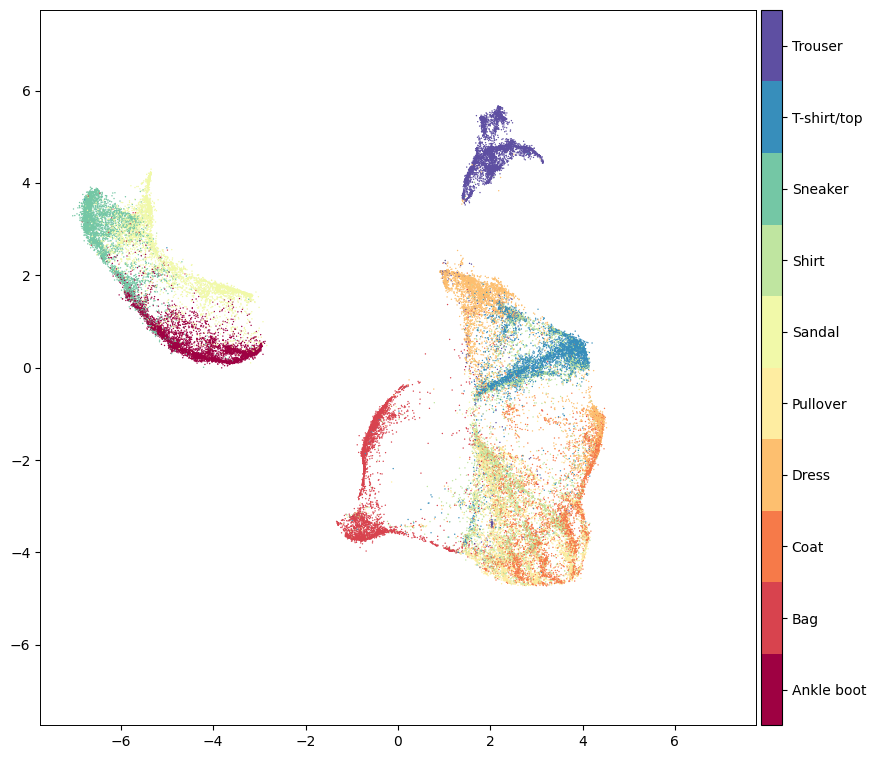

In [10]:
import pymde
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Apply PyMDE
embedding = pymde.preserve_neighbors(train_images_scaled, verbose=True).embed(verbose=True)

# Create DataFrame
df = pd.DataFrame(embedding, columns=('x', 'y'))
df["class"] = train_labels

# Replace Class Labels
labels = {0: 'T-shirt/top', 1: 'Trouser', 2: 'Pullover', 3: 'Dress', 4: 'Coat', 
          5: 'Sandal', 6: 'Shirt', 7: 'Sneaker', 8: 'Bag', 9: 'Ankle boot'}
df["class"].replace(labels, inplace=True)

# Visualize the results with PyMDE's built-in plot function
pymde.plot(embedding, color_by=df["class"])

Oct 26 02:40:54 AM: Fitting a standardized embedding into R^2, for a graph with 48000 items and 870856 edges.
Oct 26 02:40:54 AM: `embed` method parameters: eps=1.0e-05, max_iter=300, memory_size=10
Oct 26 02:40:54 AM: iteration 000 | distortion 0.215469 | residual norm 0.0192405 | step length 0.591435 | percent change 0.00367271
Oct 26 02:40:57 AM: iteration 030 | distortion 0.136328 | residual norm 0.000302002 | step length 1 | percent change 1.1536
Oct 26 02:40:59 AM: iteration 060 | distortion 0.133854 | residual norm 0.000127866 | step length 1 | percent change 0.464647
Oct 26 02:41:02 AM: iteration 090 | distortion 0.133496 | residual norm 7.79535e-05 | step length 1 | percent change 0.234345
Oct 26 02:41:05 AM: iteration 120 | distortion 0.133171 | residual norm 6.47879e-05 | step length 1 | percent change 0.933793
Oct 26 02:41:07 AM: iteration 150 | distortion 0.132735 | residual norm 9.33856e-05 | step length 1 | percent change 0.182463
Oct 26 02:41:10 AM: iteration 180 | dist

<Axes: >

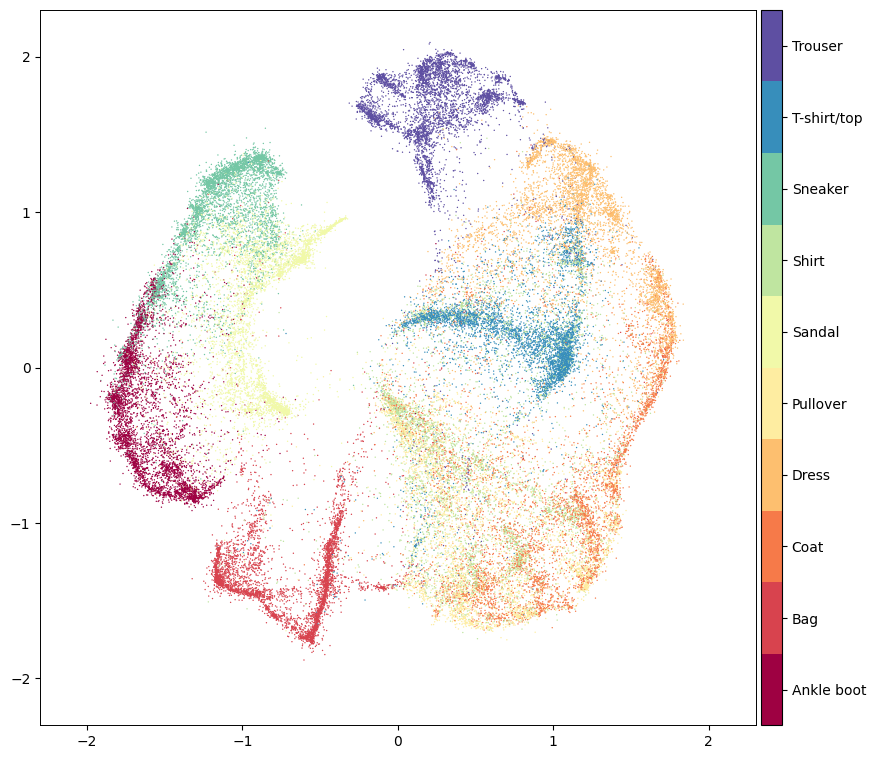

In [11]:
# Standardizes the embedding to have zero mean and unit variance

import pymde
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Apply PyMDE with constraint
embedding = pymde.preserve_neighbors(train_images_scaled, constraint=pymde.Standardized()).embed(verbose=True)

# Create DataFrame
df = pd.DataFrame(embedding, columns=('x', 'y'))
df["class"] = train_labels

# Replace Class Labels
labels = {0: 'T-shirt/top', 1: 'Trouser', 2: 'Pullover', 3: 'Dress', 4: 'Coat', 
          5: 'Sandal', 6: 'Shirt', 7: 'Sneaker', 8: 'Bag', 9: 'Ankle boot'}
df["class"].replace(labels, inplace=True)

# Visualize the results with PyMDE's built-in plot function
pymde.plot(embedding, color_by=df["class"])

Oct 26 02:49:15 AM: Fitting a standardized embedding into R^2, for a graph with 48000 items and 580676 edges.
Oct 26 02:49:15 AM: `embed` method parameters: eps=1.0e-05, max_iter=300, memory_size=10
Oct 26 02:49:15 AM: iteration 000 | distortion 0.012771 | residual norm 1.2058e-07 | step length 1.01 | percent change 3.9306e-08
Oct 26 02:49:15 AM: Converged in 001 iterations, with residual norm 1.2058e-07
Oct 26 02:49:15 AM: Finished fitting in 0.168 seconds and 1 iterations.
Oct 26 02:49:15 AM: average distortion 0.0128 | residual norm 1.2e-07


<Axes: >

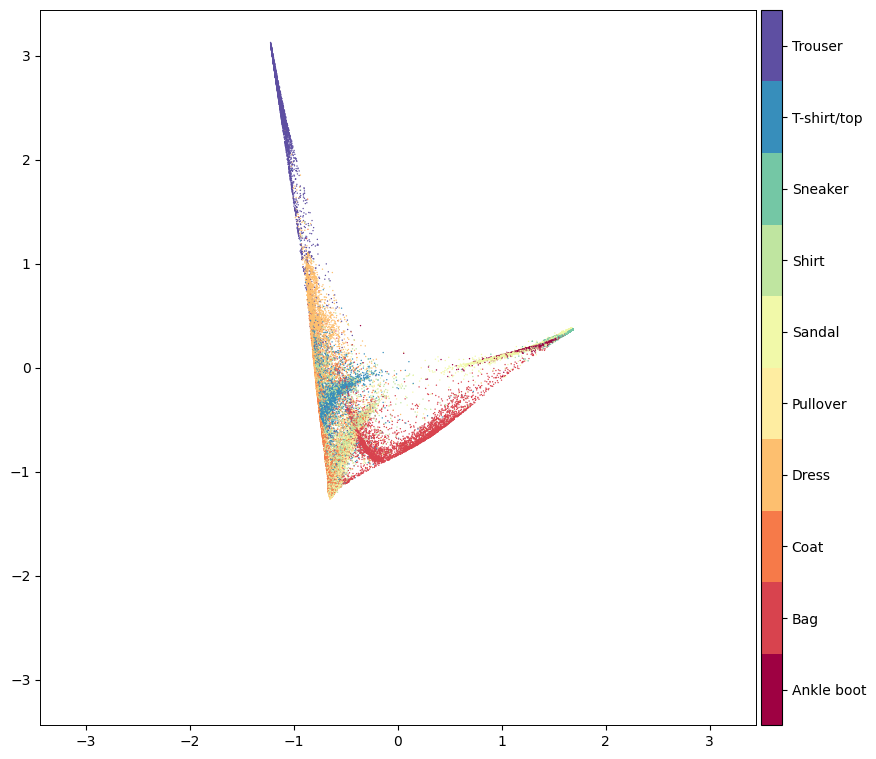

In [12]:
import pymde
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Apply PyMDE with constraint and penalties
embedding = pymde.preserve_neighbors(
    train_images_scaled,
    constraint=pymde.Standardized(),
    attractive_penalty=pymde.penalties.Quadratic,
    repulsive_penalty=None
).embed(verbose=True)

# Create DataFrame
df = pd.DataFrame(embedding, columns=('x', 'y'))
df["class"] = train_labels

# Replace Class Labels
labels = {0: 'T-shirt/top', 1: 'Trouser', 2: 'Pullover', 3: 'Dress', 4: 'Coat', 
          5: 'Sandal', 6: 'Shirt', 7: 'Sneaker', 8: 'Bag', 9: 'Ankle boot'}
df["class"].replace(labels, inplace=True)

# Visualize the results with PyMDE's built-in plot function
pymde.plot(embedding, color_by=df["class"])

### Summary of Differences

#### Without Constraints:
- **Constraints**: None.
- **Penalties**: Default attractive and repulsive penalties.
- **Behavior**: Purely preserves neighborhood structure without additional modifications.

#### With Standardized Constraint:
- **Constraints**: `pymde.Standardized()` ensures zero mean and unit variance.
- **Penalties**: Default attractive and repulsive penalties.
- **Behavior**: Standardizes the embedding, making it more interpretable and ensuring consistent scaling.

#### With Standardized Constraint and Custom Penalties:
- **Constraints**: `pymde.Standardized()` ensures zero mean and unit variance.
- **Penalties**: `pymde.penalties.Quadratic` for attractive forces, no repulsive penalty.
- **Behavior**: Standardizes the embedding and uses a quadratic penalty for attractive forces while ignoring repulsive forces, leading to different clustering behavior and distances between points.

### Visual Impact

#### Without Constraints:
- The embedding may have arbitrary scaling and mean, making it less interpretable.

#### With Standardized Constraint:
- The embedding will have consistent scaling and zero mean, making it easier to interpret and compare.

#### With Standardized Constraint and Custom Penalties:
- The embedding will have consistent scaling and zero mean, with different clustering behavior due to the custom penalties, potentially highlighting different structures in the data.

### Quadratic MDE problems

Oct 26 03:10:46 AM: Fitting a standardized embedding into R^2, for a graph with 48000 items and 542608 edges.
Oct 26 03:10:46 AM: `embed` method parameters: eps=1.0e-05, max_iter=300, memory_size=10
Oct 26 03:10:46 AM: iteration 000 | distortion 20.777769 | residual norm 0.0751578 | step length 652.587 | percent change 15.8298
Oct 26 03:10:48 AM: iteration 030 | distortion 0.516981 | residual norm 0.00672392 | step length 0.429324 | percent change 4.44899
Oct 26 03:10:50 AM: iteration 060 | distortion 0.193014 | residual norm 0.00232909 | step length 1 | percent change 2.90391
Oct 26 03:10:52 AM: iteration 090 | distortion 0.088384 | residual norm 0.00119583 | step length 1 | percent change 0.480754
Oct 26 03:10:54 AM: iteration 120 | distortion 0.061530 | residual norm 0.00109286 | step length 1 | percent change 1.03312
Oct 26 03:10:55 AM: iteration 150 | distortion 0.057119 | residual norm 0.000251967 | step length 1 | percent change 0.708582
Oct 26 03:10:57 AM: iteration 180 | disto

<Axes: >

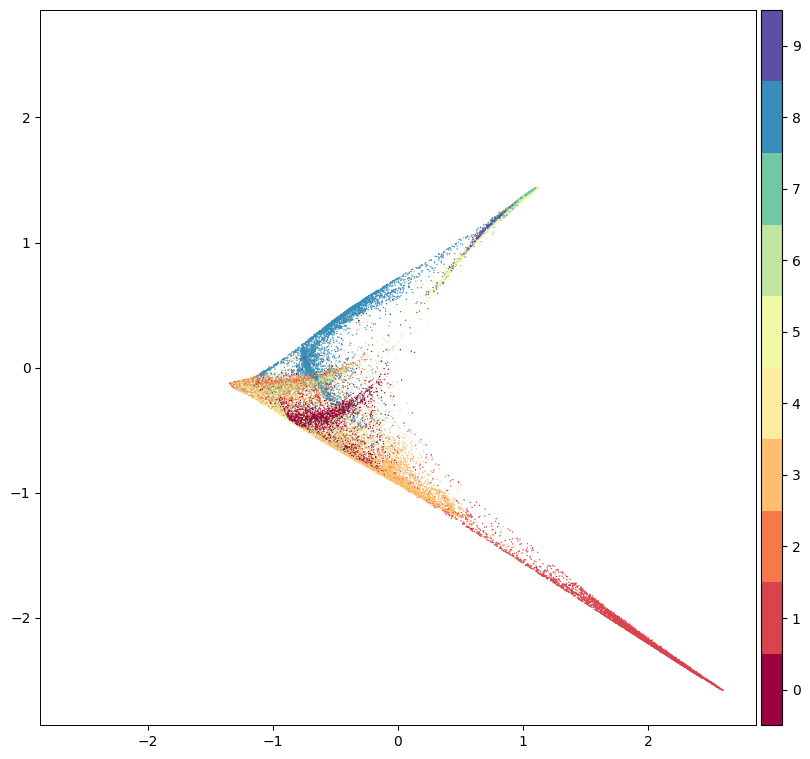

In [16]:
import pymde
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pynndescent
import torch

# Assuming train_images_scaled and train_labels are already defined and normalized

# Compute k-nearest neighbors graph using pynndescent
knn_index = pynndescent.NNDescent(train_images_scaled, n_neighbors=15, metric='euclidean')
knn_indices, knn_distances = knn_index.neighbor_graph

# Create edges and weights for the knn_graph
edges = [(i, knn_indices[i, j]) for i in range(knn_indices.shape[0]) for j in range(knn_indices.shape[1])]
edges = torch.tensor(edges, dtype=torch.int64)
weights = torch.tensor(knn_distances.flatten(), dtype=torch.float32)

# Define knn_graph using pymde.Graph.from_edges
knn_graph = pymde.Graph.from_edges(edges, weights)

# Create 2D MDE with Quadratic distortion function and Standardized constraint
quadratic_mde_2d = pymde.MDE(
    n_items=train_images_scaled.shape[0],
    embedding_dim=2,
    edges=knn_graph.edges,
    distortion_function=pymde.penalties.Quadratic(knn_graph.weights),
    constraint=pymde.Standardized()
)

# Embed and plot 2D MDE
quadratic_mde_2d.embed(verbose=True)
quadratic_mde_2d.plot(color_by=train_labels)

Oct 26 03:11:43 AM: Fitting a standardized embedding into R^3, for a graph with 48000 items and 542608 edges.
Oct 26 03:11:43 AM: `embed` method parameters: eps=1.0e-05, max_iter=300, memory_size=10
Oct 26 03:11:43 AM: iteration 000 | distortion 31.147709 | residual norm 0.0921415 | step length 489.911 | percent change 11.8957
Oct 26 03:11:45 AM: iteration 030 | distortion 0.794970 | residual norm 0.00755417 | step length 1 | percent change 6.58666
Oct 26 03:11:47 AM: iteration 060 | distortion 0.222010 | residual norm 0.00327813 | step length 1 | percent change 5.28918
Oct 26 03:11:48 AM: iteration 090 | distortion 0.153187 | residual norm 0.00080756 | step length 1 | percent change 0.287227
Oct 26 03:11:50 AM: iteration 120 | distortion 0.147337 | residual norm 0.000297684 | step length 1 | percent change 0.396447
Oct 26 03:11:52 AM: iteration 150 | distortion 0.144981 | residual norm 0.00030857 | step length 1 | percent change 0.308152
Oct 26 03:11:54 AM: iteration 180 | distortion 

<Axes3D: >

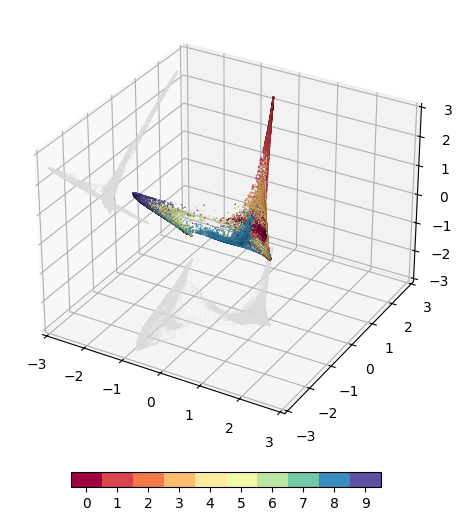

In [17]:
# Create 3D MDE with Quadratic distortion function and Standardized constraint
quadratic_mde_3d = pymde.MDE(
    n_items=train_images_scaled.shape[0],
    embedding_dim=3,
    edges=knn_graph.edges,
    distortion_function=pymde.penalties.Quadratic(knn_graph.weights),
    constraint=pymde.Standardized()
)

# Embed and plot 3D MDE
quadratic_mde_3d.embed(verbose=True)
quadratic_mde_3d.plot(color_by=train_labels)

### Summary

This code demonstrates how to use PyMDE (Minimum Distortion Embedding) to create 2D and 3D visualizations of the Fashion MNIST dataset. The process involves the following steps:

1. **Compute k-Nearest Neighbors Graph**: Using `pynndescent`, we compute the k-nearest neighbors graph for the scaled training images. This graph captures the local neighborhood structure of the data.

2. **Create Edges and Weights**: We create a list of edges and corresponding weights from the k-nearest neighbors graph. These are then converted to `torch.Tensor` objects, which are required by PyMDE.

3. **Define Graph**: Using `pymde.Graph.from_edges`, we define the graph structure that will be used for the embedding.

4. **Create and Embed MDE**: We create two instances of the `MDE` class:
   - **2D Embedding**: A 2-dimensional embedding with a quadratic distortion function and standardized constraint.
   - **3D Embedding**: A 3-dimensional embedding with the same settings.

5. **Visualize**: We embed the data and visualize the results using PyMDE's built-in plotting functions, coloring the points by their class labels.

### Purpose

- **Preserve Neighborhood Structure**: PyMDE aims to create embeddings that preserve the local neighborhood structure of the data, minimizing distortion.
- **Standardization**: The `Standardized` constraint ensures that the resulting embeddings have zero mean and unit variance, making them more interpretable and consistent.
- **Quadratic Distortion Function**: The quadratic distortion function helps in maintaining the distances between points in the embedding space, ensuring that similar points remain close to each other.

### Why Use This?

- **Dimensionality Reduction**: Reducing the dimensionality of high-dimensional data makes it easier to visualize and analyze.
- **Interpretability**: Standardized embeddings are easier to interpret and compare.
- **Preserve Data Structure**: By preserving the neighborhood structure, PyMDE ensures that the essential relationships in the data are maintained in the lower-dimensional space.

This approach is particularly useful for visualizing complex datasets like Fashion MNIST, where understanding the relationships between different classes can provide valuable insights.